# Лабораторная работа №5
*Аппроксимация табличных данных: задачи оптимизации и машинного обучения*

Вариант №10.


In [1]:
import json
import os
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-cache")

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize

try:
    OUT_DIR = Path(__file__).resolve().parent
except NameError:
    OUT_DIR = Path.cwd()


## Исходные данные


In [2]:
data = np.array(
    [
        [0.87, 1.08, -0.09],
        [2.02, 2.00, 1.23],
        [2.87, 3.09, 4.01],
        [3.92, 3.98, 3.48],
        [4.94, 5.01, 0.61],
    ],
    dtype=float,
)

X = data[:, 0]
Y = data[:, 1]
Z = data[:, 2]
XY = data[:, :2]


In [3]:
def mse(y_true, y_pred):
    return float(np.mean((y_true - y_pred) ** 2))


def residuals(y_true, y_pred):
    return y_true - y_pred


In [4]:
for i, (x, y, z) in enumerate(data):
    print(f"Точка {i}: x={x:.2f}, y={y:.2f}, z={z:.2f}")


Точка 0: x=0.87, y=1.08, z=-0.09
Точка 1: x=2.02, y=2.00, z=1.23
Точка 2: x=2.87, y=3.09, z=4.01
Точка 3: x=3.92, y=3.98, z=3.48
Точка 4: x=4.94, y=5.01, z=0.61


## Задание 1. Аппроксимация двумерной гауссианой


### Функция Гаусса


In [5]:
def gauss_2d(x, y, amplitude, x0, y0, sigma_x, sigma_y, theta, offset):
    x_rot = (x - x0) * np.cos(theta) + (y - y0) * np.sin(theta)
    y_rot = -(x - x0) * np.sin(theta) + (y - y0) * np.cos(theta)
    exponent = -(
        x_rot**2 / (2.0 * sigma_x**2)
        + y_rot**2 / (2.0 * sigma_y**2)
    )
    return amplitude * np.exp(exponent) + offset


### Loss-функция и обучение


In [6]:
def gaussian_loss(params):
    return mse(Z, gauss_2d(X, Y, *params))


def train_gaussian():
    max_idx = int(np.argmax(Z))
    start = np.array(
        [
            Z[max_idx] + 0.1,
            X[max_idx],
            Y[max_idx],
            np.std(X) * 0.5,
            np.std(Y) * 0.5,
            0.0,
            0.0,
        ],
        dtype=float,
    )
    bounds = [
        (0.1, 10.0),
        (0.0, 6.0),
        (0.0, 6.0),
        (0.1, 5.0),
        (0.1, 5.0),
        (-np.pi / 4.0, np.pi / 4.0),
        (-2.0, 2.0),
    ]
    history = [gaussian_loss(start)]

    def callback(params):
        history.append(gaussian_loss(params))

    result = minimize(
        gaussian_loss,
        start,
        method="L-BFGS-B",
        bounds=bounds,
        callback=callback,
        options={"maxiter": 20_000, "ftol": 1e-15, "gtol": 1e-12},
    )
    predictions = gauss_2d(X, Y, *result.x)
    return {
        "start": start,
        "params": result.x,
        "predictions": predictions,
        "residuals": residuals(Z, predictions),
        "mse": gaussian_loss(result.x),
        "history": np.array(history),
        "success": bool(result.success),
        "message": result.message,
    }


In [7]:
gaussian = train_gaussian()
print("Параметры [A, x0, y0, sigma_x, sigma_y, theta, offset]:")
print(np.array2string(gaussian["params"], precision=8))
print(f"MSE = {gaussian['mse']:.12g}")


Параметры [A, x0, y0, sigma_x, sigma_y, theta, offset]:
[ 4.70089609  3.4100173   3.28632342  1.22140097  1.23528345  0.02504844
 -0.19950897]
MSE = 6.55663089484e-17


## Задание №2

In [8]:
def paraboloid_2d(x, y, x0, y0, z0, a, b, c):
    dx = x - x0
    dy = y - y0
    z = a * dx**2 + b * dy**2 + z0
    return z

In [9]:
best_loss = np.inf
loss_history = []

def loss_function_paraboloid(params):
    global best_loss
    
    x0, y0, z0, a, b, c = params
    
    predictions = []
    for i in range(len(X)):
        pred = paraboloid_2d(X[i], Y[i], x0, y0, z0, a, b, c)
        predictions.append(pred)
    
    errors = np.array(predictions) - np.array(Z)
    mse = 0.5 * np.mean(errors**2)
    
    # логируем только улучшение
    if mse < best_loss:
        best_loss = mse
        loss_history.append(mse)
    
    return mse

In [10]:
X_np = np.array(X)
Y_np = np.array(Y)
Z_np = np.array(Z)

X_np = (np.array(X) - np.mean(X)) / np.std(X)
Y_np = (np.array(Y) - np.mean(Y)) / np.std(Y)
Z_np = np.array(Z)


X_mat = np.column_stack([X_np**2, Y_np**2, X_np*Y_np, X_np, Y_np, np.ones(len(X_np))])
params_standard = np.linalg.lstsq(X_mat, Z_np, rcond=None)[0]
a_st, b_st, c_st, d_st, e_st, f_st = params_standard


if abs(a_st) > 1e-6 and abs(b_st) > 1e-6:
    A_mat = np.array([[2*a_st, c_st], [c_st, 2*b_st]])
    b_vec = np.array([-d_st, -e_st])
    sol = np.linalg.solve(A_mat, b_vec)
    x0_init, y0_init = sol
else:
    x0_init = np.mean(X)
    y0_init = np.mean(Y)


z0_init = paraboloid_2d(x0_init, y0_init, x0_init, y0_init, 0, a_st, b_st, c_st) + f_st

a_init = max(abs(a_st), 0.1)
b_init = max(abs(b_st), 0.1)
c_init = c_st * 0.5

print("Начальные параметры в канонической форме (из МНК):")
print(f"  x0 = {x0_init:.4f}")
print(f"  y0 = {y0_init:.4f}")
print(f"  z0 = {z0_init:.4f}")
print(f"  a = {a_init:.4f}")
print(f"  b = {b_init:.4f}")
print(f"  c = {c_init:.4f}")

Начальные параметры в канонической форме (из МНК):
  x0 = 0.1245
  y0 = 0.1303
  z0 = 3.8634
  a = 6.5656
  b = 8.1300
  c = -0.2260


In [11]:
params_init_canonical = [x0_init, y0_init, z0_init, a_init, b_init, c_init]
bounds_canonical = [
    (-10, 10),      # x0
    (-10, 10),      # y0
    (-50, 50),      # z0
    (0.01, 100),    # a > 0
    (0.01, 100),    # b > 0
    (-5, 5)
]


result_canonical = minimize(
    loss_function_paraboloid,
    params_init_canonical,
    method='L-BFGS-B',
    bounds=bounds_canonical,
    options={'ftol': 1e-12, 'gtol': 1e-10, 'maxiter': 100}
)

x0_opt, y0_opt, z0_opt, a_opt_e, b_opt_e, c_opt_e = result_canonical.x

print("ОПТИМАЛЬНЫЕ ПАРАМЕТРЫ ЭЛЛИПТИЧЕСКОГО ПАРАБОЛОИДА")
print("="*70)
print(f"Каноническая форма:")
print(f"z = {a_opt_e:.6f}(x-{x0_opt:.4f})² + {b_opt_e:.6f}(y-{y0_opt:.4f})² + {c_opt_e:.6f}(x-{x0_opt:.4f})(y-{y0_opt:.4f}) + {z0_opt:.6f}")

# Вычисляем ошибку
predictions_e = []
for i in range(len(X)):
    z_pred = paraboloid_2d(X[i], Y[i], x0_opt, y0_opt, z0_opt, a_opt_e, b_opt_e, c_opt_e)
    predictions_e.append(z_pred)

residuals_e = np.array(Z) - np.array(predictions_e)
mse_e = 0.5 * np.mean(residuals_e**2)
rmse_e = np.sqrt(mse_e)

print(f"Финальная ошибка (MSE): {mse_e:.8f}")
print(f"Среднеквадратическая ошибка (RMSE): {rmse_e:.8f}")
print(f"Количество итераций: {len(loss_history)}")
print(f"Вершина параболоида:")
print(f"  (x, y, z) = ({x0_opt:.4f}, {y0_opt:.4f}, {z0_opt:.4f})")

ОПТИМАЛЬНЫЕ ПАРАМЕТРЫ ЭЛЛИПТИЧЕСКОГО ПАРАБОЛОИДА
Каноническая форма:
z = 0.010000(x--1.9384)² + 0.010000(y--10.0000)² + -0.225961(x--1.9384)(y--10.0000) + -0.126328
Финальная ошибка (MSE): 1.21465129
Среднеквадратическая ошибка (RMSE): 1.10211219
Количество итераций: 161
Вершина параболоида:
  (x, y, z) = (-1.9384, -10.0000, -0.1263)


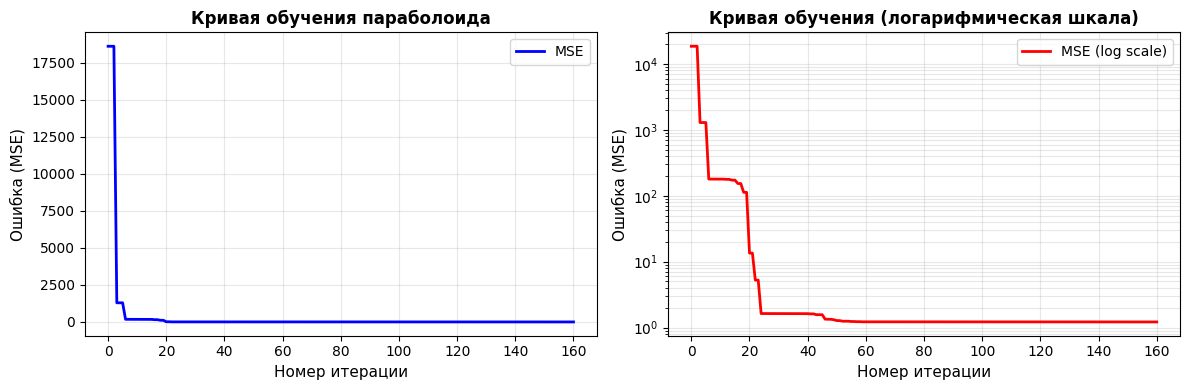

In [12]:
# Кривая обучения (лосс как функция номера итерации)
fig_loss = plt.figure(figsize=(12, 4))

# График 1: Кривая обучения
ax_loss = fig_loss.add_subplot(121)
ax_loss.plot(loss_history, 'b-', linewidth=2, label='MSE')
ax_loss.set_xlabel('Номер итерации', fontsize=11)
ax_loss.set_ylabel('Ошибка (MSE)', fontsize=11)
ax_loss.set_title('Кривая обучения параболоида', fontsize=12, fontweight='bold')
ax_loss.grid(True, alpha=0.3)
ax_loss.legend()

# График 2: Логарифмическая шкала для лучшей видимости
ax_loss_log = fig_loss.add_subplot(122)
ax_loss_log.semilogy(loss_history, 'r-', linewidth=2, label='MSE (log scale)')
ax_loss_log.set_xlabel('Номер итерации', fontsize=11)
ax_loss_log.set_ylabel('Ошибка (MSE)', fontsize=11)
ax_loss_log.set_title('Кривая обучения (логарифмическая шкала)', fontsize=12, fontweight='bold')
ax_loss_log.grid(True, alpha=0.3, which='both')
ax_loss_log.legend()

plt.tight_layout()
plt.savefig('learning_curve_paraboloid.png', dpi=300)
plt.show()

In [13]:
for x,y,z in zip(X,Y,Z):
    print(
        paraboloid_2d(x, y, x0_opt, y0_opt, z0_opt, a_opt_e, b_opt_e, c_opt_e)
    )
    print(
        z
    )
    print(
        z - paraboloid_2d(x, y, x0_opt, y0_opt, z0_opt, a_opt_e, b_opt_e, c_opt_e)
    )
    print()

1.180206250675861
-0.09
-1.2702062506758611

1.470360073309065
1.23
-0.24036007330906495

1.818358594385781
4.01
2.191641405614219

2.1712826498334894
3.48
1.3087173501665106

2.599794675125548
0.61
-1.9897946751255482



In [14]:
paraboloid = {
    "params": np.array([x0_opt, y0_opt, z0_opt, a_opt_e, b_opt_e, c_opt_e], dtype=float),
    "predictions": np.array(predictions_e, dtype=float),
    "residuals": residuals_e,
    "mse": mse_e,
    "history": np.array(loss_history, dtype=float),
    "success": bool(result_canonical.success),
    "message": result_canonical.message,
}

print("Данные параболоида сохранены в словарь paraboloid для следующих ячеек.")


Данные параболоида сохранены в словарь paraboloid для следующих ячеек.


## Задание 3. Константные модели


In [15]:
def train_constant_models():
    mean_value = float(np.mean(Z))
    median_value = float(np.median(Z))
    mean_predictions = np.full_like(Z, mean_value)
    median_predictions = np.full_like(Z, median_value)
    return {
        "mse_constant": mean_value,
        "mae_constant": median_value,
        "mse_residuals": residuals(Z, mean_predictions),
        "mae_residuals": residuals(Z, median_predictions),
        "mse": mse(Z, mean_predictions),
        "mae": float(np.mean(np.abs(residuals(Z, median_predictions)))),
    }


In [16]:
constants = train_constant_models()
print(f"Минимум MSE: z = mean(Z) = {constants['mse_constant']:.6f}")
print(f"Минимум MAE: z = median(Z) = {constants['mae_constant']:.6f}")
print("Невязки для mean:", np.array2string(constants["mse_residuals"], precision=3))
print("Невязки для median:", np.array2string(constants["mae_residuals"], precision=3))


Минимум MSE: z = mean(Z) = 1.848000
Минимум MAE: z = median(Z) = 1.230000
Невязки для mean: [-1.938 -0.618  2.162  1.632 -1.238]
Невязки для median: [-1.32  0.    2.78  2.25 -0.62]


## Задания 4-5. RBF-сеть, стратегия 2


### KMeans без sklearn


In [17]:
def kmeans_from_scratch(points, n_clusters=2, max_iter=100, eps=1e-10):
    centers = np.array([points[0], points[-1]], dtype=float)
    labels = np.zeros(len(points), dtype=int)
    for iteration in range(max_iter):
        distances = np.linalg.norm(points[:, None, :] - centers[None, :, :], axis=2)
        labels = np.argmin(distances, axis=1)
        new_centers = centers.copy()
        for cluster in range(n_clusters):
            if np.any(labels == cluster):
                new_centers[cluster] = points[labels == cluster].mean(axis=0)
        if np.linalg.norm(new_centers - centers) < eps:
            return new_centers, labels, iteration + 1
        centers = new_centers
    return centers, labels, max_iter


### Прямой проход и градиенты


In [18]:
def rbf_forward(params, points=XY):
    centers = params[:4].reshape(2, 2)
    sigmas = np.exp(params[4:6])
    w0, w1, w2 = params[6:9]
    weights = np.array([w1, w2])

    diff = points[:, None, :] - centers[None, :, :]
    r2 = np.sum(diff**2, axis=2)
    phi = np.exp(-r2 / (2.0 * sigmas[None, :] ** 2))
    predictions = w0 + phi @ weights
    return predictions, phi, diff, r2, centers, sigmas, weights


def rbf_loss_and_grad(params):
    predictions, phi, diff, r2, _, sigmas, weights = rbf_forward(params)
    error = predictions - Z
    n = len(Z)
    grad = np.zeros_like(params)

    for j in range(2):
        for coord in range(2):
            grad[2 * j + coord] = np.sum(
                2.0 * error * weights[j] * phi[:, j] * diff[:, j, coord]
                / sigmas[j] ** 2
            ) / n
        d_loss_d_sigma = np.sum(
            2.0 * error * weights[j] * phi[:, j] * r2[:, j] / sigmas[j] ** 3
        ) / n
        grad[4 + j] = d_loss_d_sigma * sigmas[j]

    grad[6] = np.sum(2.0 * error) / n
    grad[7] = np.sum(2.0 * error * phi[:, 0]) / n
    grad[8] = np.sum(2.0 * error * phi[:, 1]) / n
    return float(np.mean(error**2)), grad


### Обучение RBF-сети


In [19]:
def train_rbf_network(iterations=50_000, learning_rate=0.1):
    centers, labels, kmeans_iterations = kmeans_from_scratch(XY)
    sigma0 = np.linalg.norm(centers[0] - centers[1]) / 2.0
    rng = np.random.default_rng(10)
    start = np.concatenate(
        [
            centers.ravel(),
            np.log([sigma0, sigma0]),
            [np.mean(Z)],
            rng.normal(0.0, 0.1, size=2),
        ]
    )

    initial_loss, initial_grad = rbf_loss_and_grad(start)
    params = start.copy()
    history = []
    for iteration in range(iterations):
        loss_value, grad = rbf_loss_and_grad(params)
        history.append(loss_value)
        lr = learning_rate / (1.0 + 0.0001 * iteration)
        params -= lr * grad
    history.append(rbf_loss_and_grad(params)[0])

    predictions = rbf_forward(params)[0]
    return {
        "kmeans_centers": centers,
        "kmeans_labels": labels,
        "kmeans_iterations": kmeans_iterations,
        "start": start,
        "initial_loss": initial_loss,
        "initial_grad": initial_grad,
        "params": params,
        "predictions": predictions,
        "residuals": residuals(Z, predictions),
        "mse": mse(Z, predictions),
        "history": np.array(history),
    }


In [20]:
rbf = train_rbf_network()
print("Центры KMeans:")
print(np.array2string(rbf["kmeans_centers"], precision=8))
print("Параметры RBF [c1x, c1y, c2x, c2y, ln_sigma1, ln_sigma2, w0, w1, w2]:")
print(np.array2string(rbf["params"], precision=8))
print(f"MSE = {rbf['mse']:.12g}")


Центры KMeans:
[[1.445      1.54      ]
 [3.91       4.02666667]]
Параметры RBF [c1x, c1y, c2x, c2y, ln_sigma1, ln_sigma2, w0, w1, w2]:
[ 1.05428766  0.85708129  3.50012242  3.19049048 -0.69918883  0.17678423
 -0.10746584 -0.08314593  4.75019026]
MSE = 1.09232319151e-17


### Производные на первой итерации


In [21]:
initial_sigma2 = np.exp(rbf["start"][5])
d_loss_d_sigma2 = rbf["initial_grad"][5] / initial_sigma2
print(f"L0 = {rbf['initial_loss']:.6f}")
print(f"dL/dc2y = {rbf['initial_grad'][3]:.6f}")
print(f"dL/dsigma2 = {d_loss_d_sigma2:.6f}")
print(f"dL/dw0 = {rbf['initial_grad'][6]:.6f}")
print(f"dL/dw1 = {rbf['initial_grad'][7]:.6f}")


L0 = 2.622131
dL/dc2y = -0.017811
dL/dsigma2 = -0.007277
dL/dw0 = -0.189937
dL/dw1 = 0.325841


## Визуализация


In [22]:
def plot_learning_curve(history, title, filename):
    plt.figure(figsize=(8, 5))
    plt.plot(np.arange(len(history)), history, color="#2854a3", linewidth=1.8)
    plt.xlabel("Номер итерации")
    plt.ylabel("MSE")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.yscale("log")
    plt.tight_layout()
    plt.savefig(OUT_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()


def plot_surface(model, title, filename, cmap="viridis", centers=None):
    x_grid = np.linspace(-0.5, 6.5, 90)
    y_grid = np.linspace(-0.5, 6.5, 90)
    xx, yy = np.meshgrid(x_grid, y_grid)
    zz = model(xx, yy)

    fig = plt.figure(figsize=(16, 6))
    ax_3d = fig.add_subplot(121, projection="3d")
    surf = ax_3d.plot_surface(xx, yy, zz, cmap=cmap, alpha=0.75, edgecolor="none")
    ax_3d.scatter(X, Y, Z, c="red", s=90, edgecolors="black", label="Данные")
    if centers is not None:
        center_z = model(centers[:, 0], centers[:, 1])
        ax_3d.scatter(
            centers[:, 0],
            centers[:, 1],
            center_z,
            c="limegreen",
            marker="X",
            s=140,
            edgecolors="black",
            label="Центры RBF",
        )
    ax_3d.set_xlabel("X")
    ax_3d.set_ylabel("Y")
    ax_3d.set_zlabel("Z")
    ax_3d.set_title(f"{title}: поверхность")
    ax_3d.legend()
    fig.colorbar(surf, ax=ax_3d, shrink=0.55)

    ax_2d = fig.add_subplot(122)
    filled = ax_2d.contourf(xx, yy, zz, levels=28, cmap=cmap, alpha=0.85)
    lines = ax_2d.contour(xx, yy, zz, levels=15, colors="white", linewidths=0.7)
    ax_2d.clabel(lines, inline=True, fontsize=7)
    ax_2d.scatter(X, Y, c=Z, cmap=cmap, s=120, edgecolors="red", linewidth=2.0)
    if centers is not None:
        ax_2d.scatter(
            centers[:, 0],
            centers[:, 1],
            c="limegreen",
            marker="X",
            s=180,
            edgecolors="black",
        )
    ax_2d.set_xlabel("X")
    ax_2d.set_ylabel("Y")
    ax_2d.set_title(f"{title}: линии уровня")
    ax_2d.grid(True, alpha=0.25)
    ax_2d.set_xlim(-0.5, 6.5)
    ax_2d.set_ylim(-0.5, 6.5)
    fig.colorbar(filled, ax=ax_2d, label="Z")

    plt.tight_layout()
    plt.savefig(OUT_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()


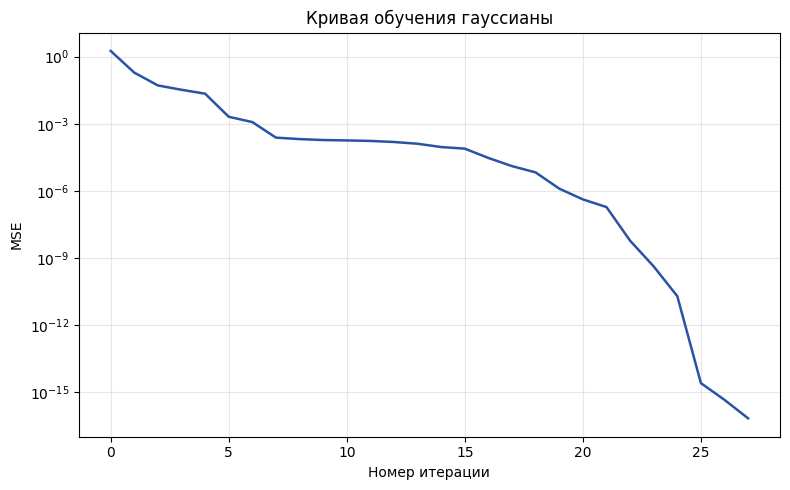

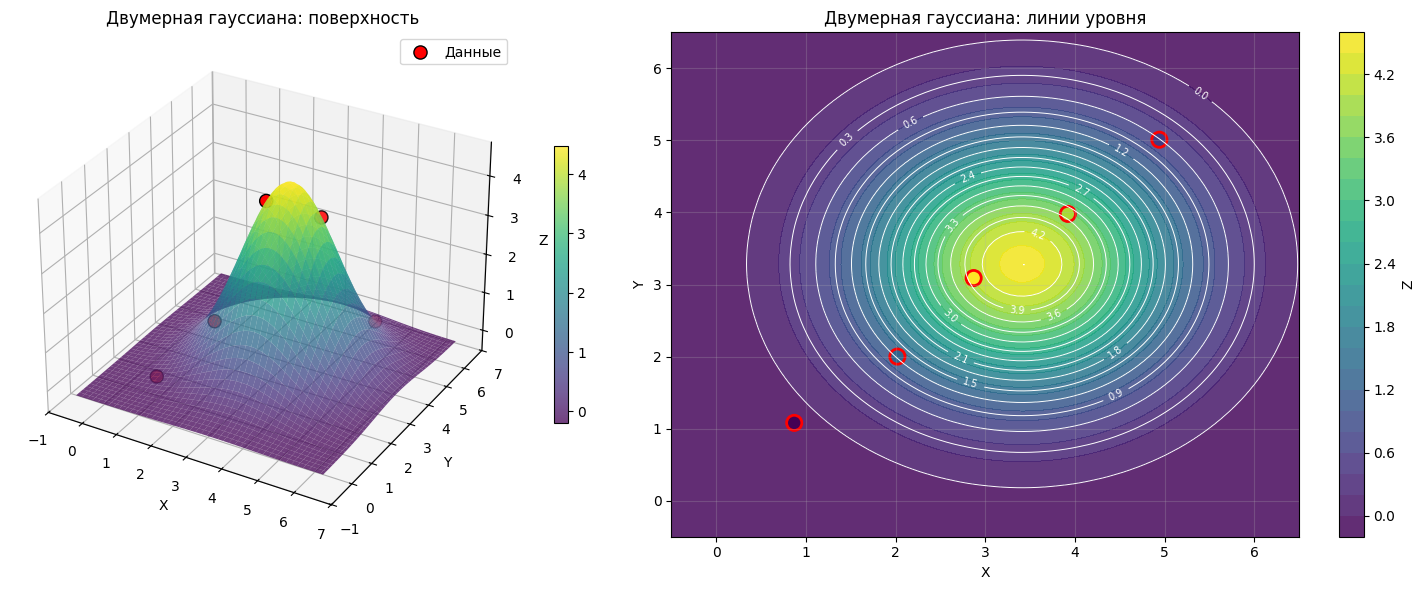

In [23]:
plot_learning_curve(
    gaussian["history"],
    "Кривая обучения гауссианы",
    "gaussian_learning_curve.png",
)
plot_surface(
    lambda x, y: gauss_2d(x, y, *gaussian["params"]),
    "Двумерная гауссиана",
    "model_plot.png",
    cmap="viridis",
)


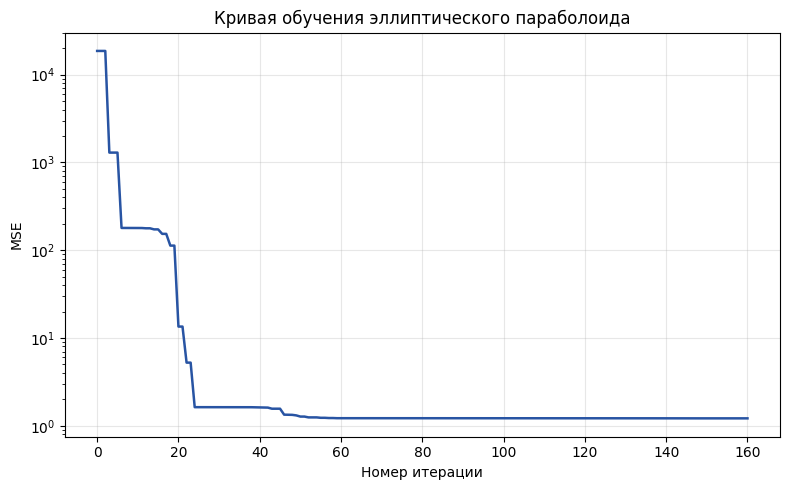

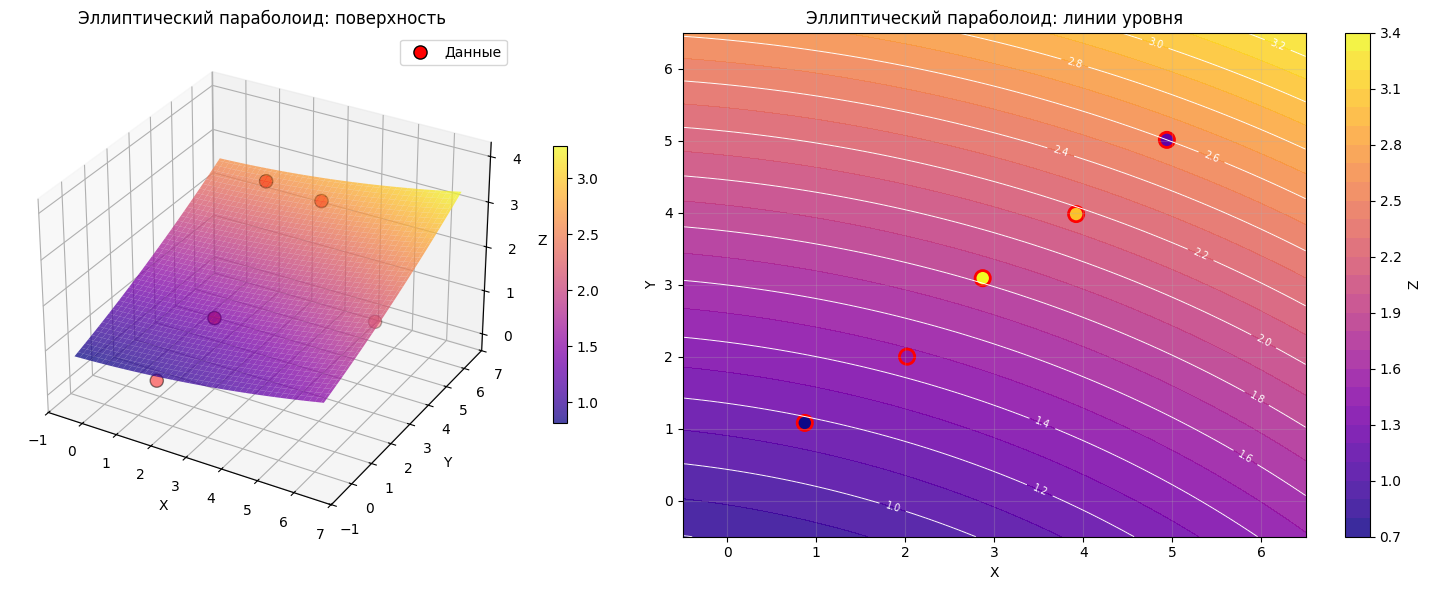

In [24]:
plot_learning_curve(
    paraboloid["history"],
    "Кривая обучения эллиптического параболоида",
    "learning_curve_paraboloid.png",
)
plot_surface(
    lambda x, y: paraboloid_2d(x, y, *paraboloid["params"]),
    "Эллиптический параболоид",
    "elliptic_paraboloid_model.png",
    cmap="plasma",
)


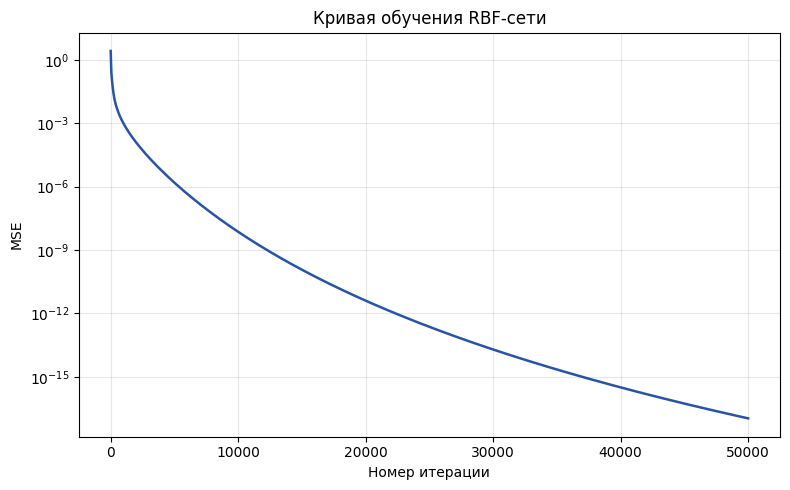

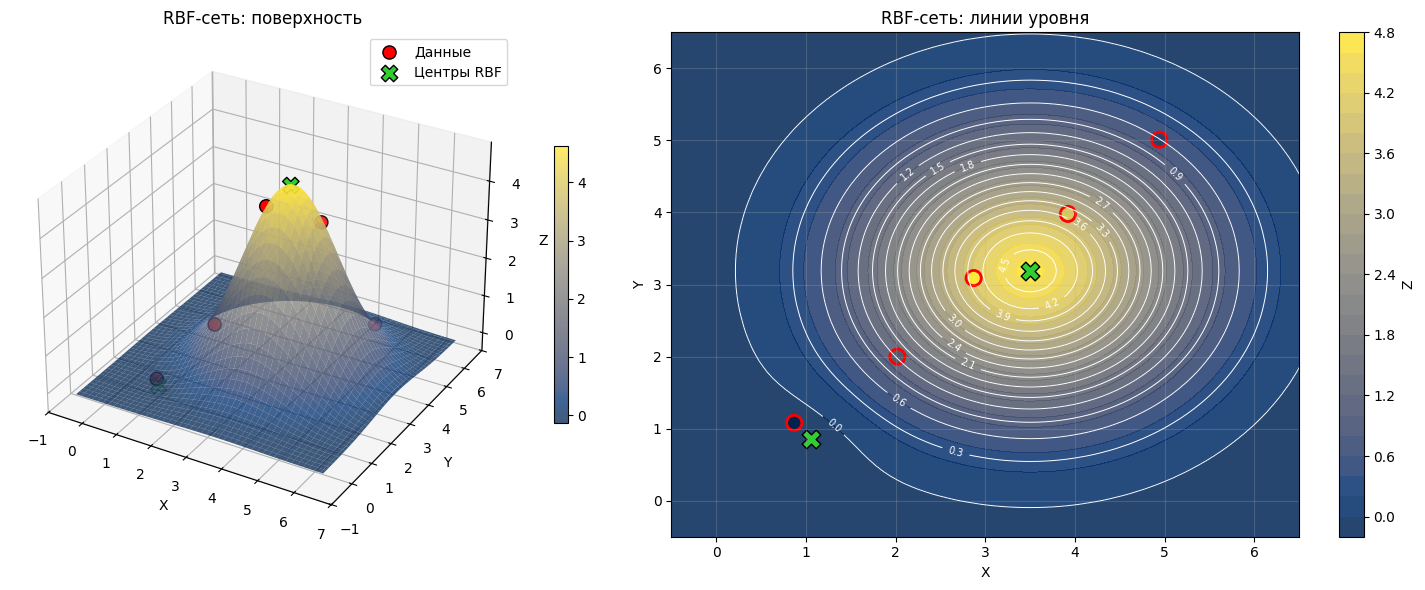

In [25]:
plot_learning_curve(
    rbf["history"],
    "Кривая обучения RBF-сети",
    "rbf_network_learning_curve.png",
)
plot_surface(
    lambda x, y: rbf_forward(rbf["params"], np.column_stack([np.ravel(x), np.ravel(y)]))[
        0
    ].reshape(np.shape(x)),
    "RBF-сеть",
    "rbf_network_model.png",
    cmap="cividis",
    centers=rbf["params"][:4].reshape(2, 2),
)
